# Thiranex Internship — Task 2
## Predictive Modeling Using Machine Learning: Employee Attrition Classification
**Author:** Pratyush  
**Method:** Logistic Regression and Random Forest; confusion matrix; ROC / AUC; threshold evaluation.  
**Data:** Fully **synthetic/fictional** employee information created for this learning project. Never present it as a real employer dataset.

**Video alignment:** The shared tutorial explains binary-classification scores, the sigmoid function, confusion matrices, varying thresholds, ROC curves and AUC using an image classification example. This notebook applies the *same evaluation concepts* to tabular employee data. It is **not a reproduction** of the video's microscopy CNN pipeline.

### 1 — Setup and dataset
Upload `employee_attrition_data.csv` using Google Colab's left Files tab. Place it in the current notebook directory. Run cells in order (Runtime → Run all).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_auc_score,
                             roc_curve, RocCurveDisplay, classification_report)

plt.rcParams['figure.dpi'] = 115
Path('charts').mkdir(exist_ok=True)
DATA_PATH = Path('employee_attrition_data.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError('Upload employee_attrition_data.csv in the Colab Files panel, then Run all.')
df = pd.read_csv(DATA_PATH)
print('Dataset shape:', df.shape)
display(df.head())

Dataset shape: (650, 10)


,Employee_ID,Age,Years_Experience,Department,Overtime,Job_Satisfaction,Monthly_Income_INR,Distance_From_Home_KM,Training_Count,Attrition
0,EMP0001,39,17,Finance,No,3,68795,24,3,No
1,EMP0002,37,3,Marketing,No,1,46219,8,6,No
2,EMP0003,27,0,Sales,No,3,20000,20,0,No
3,EMP0004,39,13,Sales,No,5,72305,13,0,No
4,EMP0005,41,7,Marketing,No,5,48873,26,6,No


### 2 — Inspect data and define target
**Target:** `Attrition` = Yes (employee leaves) or No (employee stays). Use `Yes=1` as the positive class. An employee identifier is excluded because it is not a meaningful predictor.

In [2]:
print('Missing values by column:')
print(df.isna().sum())
print('\nDuplicate employee IDs:', df['Employee_ID'].duplicated().sum())
print('\nTarget counts:')
print(df['Attrition'].value_counts())
assert set(df['Attrition'].unique()) == {'No', 'Yes'}
X = df.drop(columns=['Employee_ID', 'Attrition'])
y = df['Attrition'].map({'No': 0, 'Yes': 1})
print('\nPositive class rate:', round(y.mean(), 3))

Missing values by column:
Employee_ID              0
Age                      0
Years_Experience         0
Department               0
Overtime                 0
Job_Satisfaction         0
Monthly_Income_INR       0
Distance_From_Home_KM    0
Training_Count           0
Attrition                0
dtype: int64

Duplicate employee IDs: 0

Target counts:
Attrition
No     506
Yes    144
Name: count, dtype: int64

Positive class rate: 0.222


### 3 — Train/test split and preprocessing
Use a stratified 80/20 split and keep **all preprocessing inside pipelines** to prevent leakage from test data into training.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(exclude=['number']).columns.tolist()
preprocess = ColumnTransformer([
    ('numeric', Pipeline([('impute', SimpleImputer(strategy='median')),
                          ('scale', StandardScaler())]), num_cols),
    ('categorical', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                              ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
])
models = {
    'Logistic Regression': Pipeline([('preprocess', preprocess),
                                     ('model', LogisticRegression(max_iter=2000, random_state=42))]),
    'Random Forest': Pipeline([('preprocess', preprocess),
                               ('model', RandomForestClassifier(n_estimators=200,
                                                                min_samples_leaf=3,
                                                                random_state=42))])
}
print('Training rows:', len(X_train), '| Test rows:', len(X_test))

Training rows: 520 | Test rows: 130


### 4 — Train models and evaluate held-out test data
Accuracy alone can be misleading if one class is more common. Include precision, recall, F1 and ROC AUC.

In [4]:
scores = []
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    predictions[name] = {'labels': y_pred, 'scores': y_prob}
    scores.append({'Model': name, 'Accuracy': accuracy_score(y_test, y_pred),
                   'Precision': precision_score(y_test, y_pred, zero_division=0),
                   'Recall': recall_score(y_test, y_pred, zero_division=0),
                   'F1': f1_score(y_test, y_pred, zero_division=0),
                   'ROC_AUC': roc_auc_score(y_test, y_prob)})
results = pd.DataFrame(scores).sort_values('ROC_AUC', ascending=False)
display(results.round(3))
results.to_csv('model_metrics.csv', index=False)
print('Logistic Regression classification report:')
print(classification_report(y_test, predictions['Logistic Regression']['labels'],
                            target_names=['Stay (No)', 'Leave (Yes)']))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,Random Forest,0.808,0.643,0.310,0.419,0.809
0,Logistic Regression,0.800,0.579,0.379,0.458,0.807


Logistic Regression classification report:
              precision    recall  f1-score   support

   Stay (No)       0.84      0.92      0.88       101
 Leave (Yes)       0.58      0.38      0.46        29

    accuracy                           0.80       130
   macro avg       0.71      0.65      0.67       130
weighted avg       0.78      0.80      0.78       130



### 5 — Confusion matrices
Rows = **actual**; columns = **predicted**. With labels `[0,1]`, cells are TN, FP, FN, TP. False negatives mean an employee who leaves was predicted to stay.

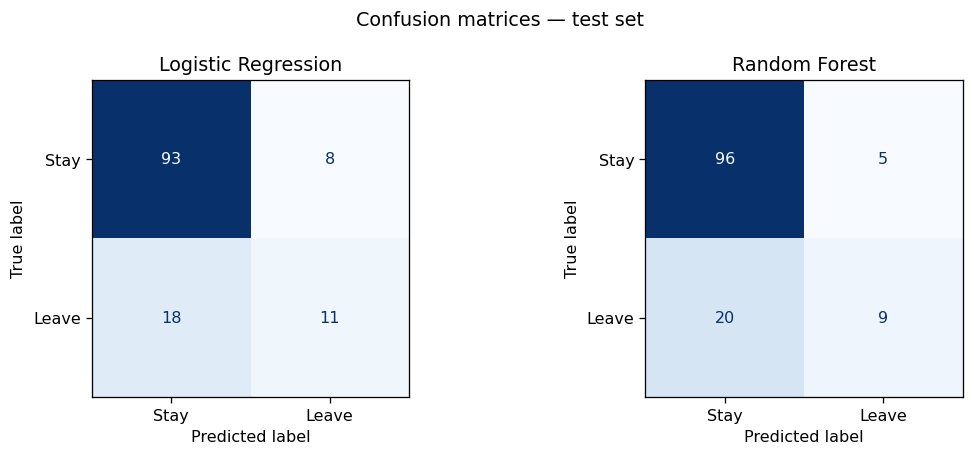

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, pred) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred['labels'], labels=[0,1]),
        display_labels=['Stay', 'Leave']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
fig.suptitle('Confusion matrices — test set')
fig.tight_layout()
fig.savefig('charts/confusion_matrices.png', bbox_inches='tight')
plt.show()

### 6 — Receiver Operating Characteristic (ROC) curves
A ROC curve plots **true positive rate** versus **false positive rate** as the classification threshold changes. AUC = 0.5 is approximately random ranking; closer to 1 is better ranking.

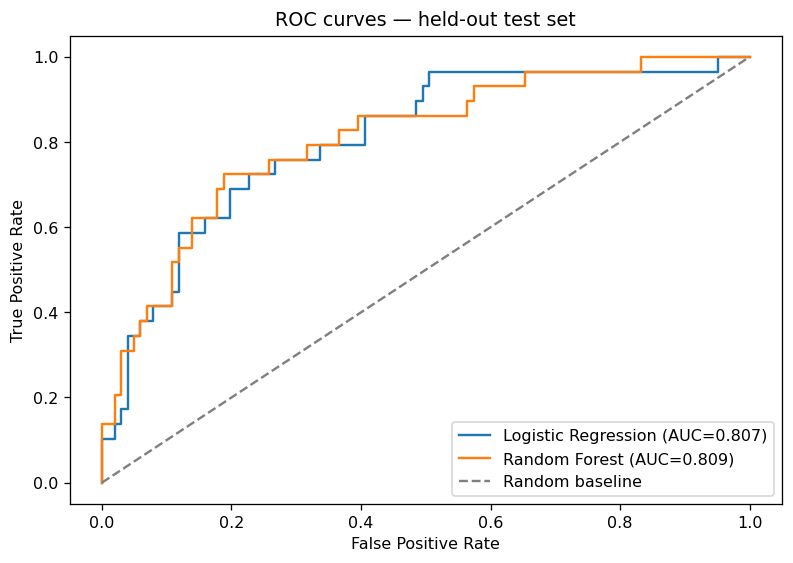

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, pred in predictions.items():
    fpr, tpr, thresholds = roc_curve(y_test, pred['scores'])
    auc = roc_auc_score(y_test, pred['scores'])
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1], linestyle='--', color='gray', label='Random baseline')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC curves — held-out test set')
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig('charts/roc_curves.png', bbox_inches='tight')
plt.show()

### 7 — Demonstrate how the decision threshold changes errors
The tutorial explains how a threshold changes predicted classes. Here we compare 0.30, 0.50, and 0.70 on the **same held-out** test set as a teaching demonstration. Do not select a production threshold using the final test set; use a separate validation set or cross-validation.

,Threshold,TN,FP,FN,TP,Precision,Recall
0,0.3,85,16,11,18,0.529,0.621
1,0.5,93,8,18,11,0.579,0.379
2,0.7,97,4,22,7,0.636,0.241


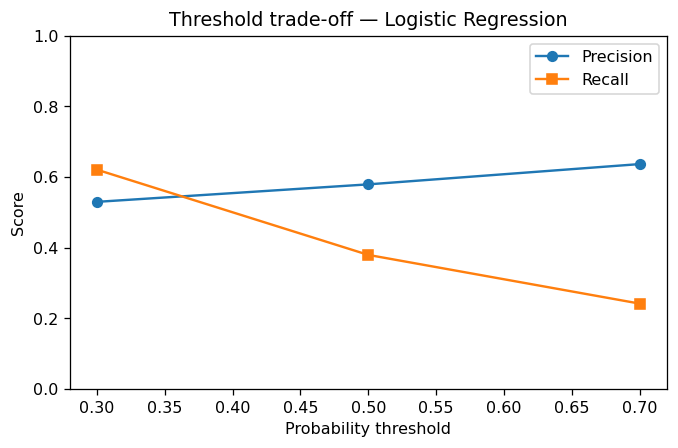

In [7]:
prob = predictions['Logistic Regression']['scores']
threshold_results = []
for threshold in [0.30, 0.50, 0.70]:
    pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0,1]).ravel()
    threshold_results.append({'Threshold': threshold, 'TN': tn, 'FP': fp,
                              'FN': fn, 'TP': tp, 'Precision': precision_score(y_test, pred, zero_division=0),
                              'Recall': recall_score(y_test, pred, zero_division=0)})
threshold_table = pd.DataFrame(threshold_results)
display(threshold_table.round(3))
threshold_table.to_csv('threshold_comparison.csv', index=False)
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(threshold_table['Threshold'], threshold_table['Precision'], marker='o', label='Precision')
ax.plot(threshold_table['Threshold'], threshold_table['Recall'], marker='s', label='Recall')
ax.set(xlabel='Probability threshold', ylabel='Score', ylim=(0,1), title='Threshold trade-off — Logistic Regression')
ax.legend()
fig.tight_layout()
fig.savefig('charts/threshold_tradeoff.png', bbox_inches='tight')
plt.show()

### 8 — Conclusions and reproducibility
Compare the trained models by F1 and ROC AUC. Look at the confusion matrix to identify false positives and false negatives. **This is a simulated demonstration only**: associations and model performance do not establish real-world employee behavior.

**Output files:** `model_metrics.csv`, `threshold_comparison.csv`, and `charts/*.png`. Download them from Colab's Files panel if you rerun the notebook there.

**Notebook prepared for Thiranex Task 2.** Review every result before submitting and be ready to explain it.